<a href="https://colab.research.google.com/github/mancinigabriel/tcc-pece-assin2-llm-challenges/blob/main/notebooks/analise_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Preparando ambiente

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

import pandas as pd
import random
import re
import time

In [3]:
import math

def categorizar_1a5(valor: float) -> int:
    if not 1.0 <= valor <= 5.0:
        raise ValueError("O valor deve estar entre 1 e 5.")

    return min(5, math.ceil(valor))

In [4]:
import os
import json

log_folder_path = '/content/drive/MyDrive/Mestrado/TCC Pós/Dados/logs'

all_logs = []

if os.path.exists(log_folder_path):
    for filename in os.listdir(log_folder_path):
        if filename.endswith('.json'):
            filepath = os.path.join(log_folder_path, filename)
            try:
                with open(filepath, 'r') as f:
                    log_data = json.load(f)
                    all_logs.append(log_data)
                print(f"Successfully read {filename}")
            except json.JSONDecodeError:
                print(f"Error decoding JSON from {filename}")
            except Exception as e:
                print(f"Error reading {filename}: {e}")
else:
    print(f"The directory {log_folder_path} does not exist.")

Successfully read log_mistral3b_reasoning_20260112_022821.json
Successfully read log_bode_7b_20260112_023227.json
Successfully read log_mistral8b_reasoning_20260112_025553.json
Successfully read log_qwen3_4b_instruct_20260112_030112.json
Successfully read log_sabia-7b_20260112_033330.json
Successfully read log_gaia_20260112_033534.json
Successfully read log_gemma_2_2b_it_20260112_033805.json
Successfully read log_qwen3_4b_thinking_20260112_034407.json
Successfully read log_gemma_2_9b_it_20260112_042832.json
Successfully read log_mistral3b_instruct_fp8_20260114_153353.json
Successfully read log_mistral8b_instruct_fp8_20260114_182551.json


In [5]:
df_logs = pd.DataFrame([log['log'] for log in all_logs])
print(df_logs.head())

                                      model            gpu  quantized  \
0   mistralai/Ministral-3-3B-Reasoning-2512  A100 RAM alta      False   
1  recogna-nlp/bode-7b-alpaca-pt-br-no-peft             L4      False   
2   mistralai/Ministral-3-8B-Reasoning-2512  A100 RAM alta      False   
3               Qwen/Qwen3-4B-Instruct-2507  A100 RAM alta      False   
4                      maritaca-ai/sabia-7b             L4      False   

                                           execution  \
0  {'inicio': '2026-01-12 02:07:11', 'inicio_test...   
1  {'inicio': '2026-01-12 02:17:11', 'inicio_test...   
2  {'inicio': '2026-01-12 02:28:21', 'inicio_test...   
3  {'inicio': '2026-01-12 02:18:46', 'inicio_test...   
4  {'inicio': '2026-01-12 02:31:26', 'inicio_test...   

                                          generation  \
0  {'temperature': 0.0, 'top_p': 1.0, 'top_k': 0,...   
1  {'temperature': 0.0, 'top_p': 1.0, 'top_k': 0,...   
2  {'temperature': 0.0, 'top_p': 1.0, 'top_k': 0,...   


In [6]:
df_execution = pd.json_normalize(df_logs['execution'])
df_generation = pd.json_normalize(df_logs['generation'])
df_metrics_main = pd.json_normalize(df_logs['metrics'])
df_metrics_consistency = pd.json_normalize(df_logs['metrics'].apply(lambda x: x['consistência']))

df_execution.columns = ['execution_' + col for col in df_execution.columns]
df_generation.columns = ['generation_' + col for col in df_generation.columns]
df_metrics_main.columns = ['metrics_' + col for col in df_metrics_main.columns]
df_metrics_consistency.columns = ['metrics_consistency_' + col for col in df_metrics_consistency.columns]

df_logs = pd.concat([
    df_logs.drop(columns=['execution', 'generation', 'metrics']),
    df_execution,
    df_generation,
    df_metrics_main.drop(columns=['metrics_consistência'], errors='ignore'),
    df_metrics_consistency
], axis=1)

In [7]:
df_logs.head(30)

,model,gpu,quantized,execution_inicio,execution_inicio_teste_consistencia,execution_fim_teste_consistencia,execution_inicio_aplicacao_completa,execution_fim,execution_duracao total,execution_duracao_teste_consistencia,...,generation_do_sample,metrics_acurácia,metrics_consistência.mean_consistency,metrics_consistência.std_consistency,metrics_consistência.min_consistency,metrics_consistência.max_consistency,metrics_consistency_mean_consistency,metrics_consistency_std_consistency,metrics_consistency_min_consistency,metrics_consistency_max_consistency
0,mistralai/Ministral-3-3B-Reasoning-2512,A100 RAM alta,False,2026-01-12 02:07:11,2026-01-12 02:07:44,2026-01-12 02:12:11,2026-01-12 02:12:11,2026-01-12 02:28:20,1268.804539,266.604221,...,False,0.878332,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0
1,recogna-nlp/bode-7b-alpaca-pt-br-no-peft,L4,False,2026-01-12 02:17:11,2026-01-12 02:17:58,2026-01-12 02:21:04,2026-01-12 02:21:04,2026-01-12 02:32:27,916.068279,185.581253,...,False,0.533856,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0
2,mistralai/Ministral-3-8B-Reasoning-2512,A100 RAM alta,False,2026-01-12 02:28:21,2026-01-12 02:29:25,2026-01-12 02:35:02,2026-01-12 02:35:02,2026-01-12 02:55:53,1652.143073,337.054451,...,False,0.886930,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0
3,Qwen/Qwen3-4B-Instruct-2507,A100 RAM alta,False,2026-01-12 02:18:46,2026-01-12 02:19:31,2026-01-12 02:28:24,2026-01-12 02:28:24,2026-01-12 03:01:12,2545.526871,532.813460,...,False,0.907674,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0
4,maritaca-ai/sabia-7b,L4,False,2026-01-12 02:31:26,2026-01-12 02:34:37,2026-01-12 02:46:07,2026-01-12 02:50:48,2026-01-12 03:33:30,3724.074934,690.352630,...,False,0.501935,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0
5,CEIA-UFG/Gemma-3-Gaia-PT-BR-4b-it,A100 RAM alta,False,2026-01-12 02:45:41,2026-01-12 02:45:52,2026-01-12 02:56:22,2026-01-12 02:56:22,2026-01-12 03:35:33,2992.028833,630.401227,...,False,0.843508,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0
6,google/gemma-2-2b-it,A100 RAM alta,False,2026-01-12 03:06:56,2026-01-12 03:07:38,2026-01-12 03:14:09,2026-01-12 03:14:09,2026-01-12 03:38:05,1868.349347,390.892891,...,False,0.779880,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0
7,Qwen/Qwen3-4B-Thinking-2507,A100 RAM alta,False,2026-01-12 03:01:12,2026-01-12 03:01:48,2026-01-12 03:10:46,2026-01-12 03:10:46,2026-01-12 03:44:07,2574.987725,538.009843,...,False,0.885533,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0
8,google/gemma-2-9b-it,A100 RAM alta,False,2026-01-12 03:38:05,2026-01-12 03:39:07,2026-01-12 03:49:38,2026-01-12 03:49:38,2026-01-12 04:28:31,3026.305757,630.556215,...,False,0.890800,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0
9,mistralai/Ministral-3-3B-Instruct-2512,L4,True,2026-01-14 14:28:35,2026-01-14 14:29:03,2026-01-14 14:42:49,2026-01-14 14:42:49,2026-01-14 15:33:52,3917.143537,825.923539,...,False,0.880052,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0


/tmp/ipython-input-3920808396.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


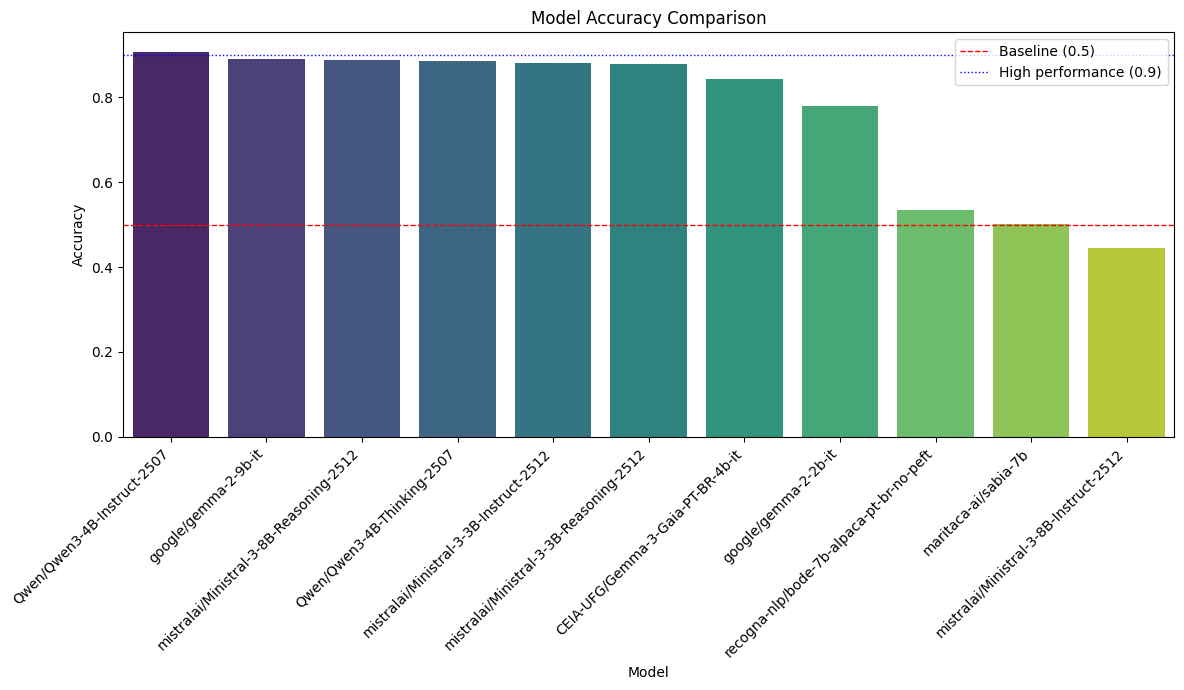

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the DataFrame by accuracy for better visualization
df_logs_sorted = df_logs.sort_values(by='metrics_acurácia', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(
    x='model',
    y='metrics_acurácia',
    data=df_logs_sorted,
    palette='viridis'
)

# Linhas de referência
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1.0, label='Baseline (0.5)')
plt.axhline(y=0.9, color='blue', linestyle=':', linewidth=1.0, label='High performance (0.9)')

plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=45, ha='right')

plt.legend()
plt.tight_layout()
plt.show()


In [9]:
import pandas as pd
import os

data_folder_path = '/content/drive/MyDrive/Mestrado/TCC Pós/Dados/completos'

dataframes = {}

if os.path.exists(data_folder_path):
    for filename in os.listdir(data_folder_path):
        if filename.endswith('.csv') and 'consistencia' not in filename:
            filepath = os.path.join(data_folder_path, filename)
            try:
                df_name = filename.replace('.csv', '') # Use filename as key
                dataframes[df_name] = pd.read_csv(filepath)
                dataframes[df_name]['match'] = (
                  dataframes[df_name]['entailment_judgment']
                  == dataframes[df_name]['pred_tratado']).astype(int)
                dataframes[df_name]['cat_sim'] = dataframes[df_name]['relatedness_score'].apply(categorizar_1a5)
                print(f"Successfully loaded '{filename}' into DataFrame '{df_name}'.")
            except Exception as e:
                print(f"Error loading '{filename}': {e}")
else:
    print(f"The directory '{data_folder_path}' does not exist.")

Successfully loaded 'dados_mistral_3b_reasoning.csv' into DataFrame 'dados_mistral_3b_reasoning'.
Successfully loaded 'dados_bode_7b.csv' into DataFrame 'dados_bode_7b'.
Successfully loaded 'dados_mistral8b_reasoning.csv' into DataFrame 'dados_mistral8b_reasoning'.
Successfully loaded 'dados_qwen3_4b_instruct.csv' into DataFrame 'dados_qwen3_4b_instruct'.
Successfully loaded 'dados_sabia-7b.csv' into DataFrame 'dados_sabia-7b'.
Successfully loaded 'dados_gaia.csv' into DataFrame 'dados_gaia'.
Successfully loaded 'dados_gemma_2_2b_it.csv' into DataFrame 'dados_gemma_2_2b_it'.
Successfully loaded 'dados_qwen3_4b_thinking.csv' into DataFrame 'dados_qwen3_4b_thinking'.
Successfully loaded 'dados_gemma_2_9b_it.csv' into DataFrame 'dados_gemma_2_9b_it'.
Successfully loaded 'dados_mistral3b_instruct_fp8.csv' into DataFrame 'dados_mistral3b_instruct_fp8'.
Successfully loaded 'dados_mistral8b_instruct_fp8.csv' into DataFrame 'dados_mistral8b_instruct_fp8'.


In [13]:
dataframes['dados_bode_7b']

,Unnamed: 0,sentence_pair_id,premise,hypothesis,relatedness_score,entailment_judgment,pred,pred_tratado,match,cat_sim
0,0,1,Uma criança risonha está segurando uma pistola...,Uma criança está segurando uma pistola de água,4.5,1,1,1,1,5
1,1,2,Os homens estão cuidadosamente colocando as ma...,Os homens estão colocando bagagens dentro do p...,4.5,1,1,1,1,5
2,2,3,Uma pessoa tem cabelo loiro e esvoaçante e est...,Um guitarrista tem cabelo loiro e esvoaçante,4.7,1,1,1,1,5
3,3,4,Batatas estão sendo fatiadas por um homem,O homem está fatiando a batata,4.7,1,1,1,1,5
4,4,5,Um caminhão está descendo rapidamente um morro,Um caminhão está rapidamente descendo o morro,4.9,1,1,1,1,5
...,...,...,...,...,...,...,...,...,...,...
9299,9299,496,Um gato está tocando teclados,Um gato está tocando um piano comicamente,3.9,0,1,1,0,4
9300,9300,497,A mulher está rachando ovos em uma tigela,A senhora não está quebrando ovos na tigela,3.6,0,1,1,0,4
9301,9301,498,Um homem de patins está patinando em uma pista...,Um homem de patins está patinando em uma pista...,4.7,1,1,1,1,5
9302,9302,499,Uma tartaruga de mar está procurando peixes,O peixe está seguindo a tartaruga,3.2,0,1,1,0,4


In [16]:
combined_df_list = []

for model_name, df in dataframes.items():
    df_copy = df.copy()
    df_copy['model_name'] = model_name
    df_copy['entailment_judgment_label'] = df_copy['entailment_judgment'].map({0: 'Not Entailment', 1: 'Entailment'})
    combined_df_list.append(df_copy)

combined_df = pd.concat(combined_df_list, ignore_index=True)

mean_match_by_judgment = combined_df.groupby(['model_name', 'entailment_judgment_label'])['match'].mean().reset_index()

print("Mean match by model and entailment judgment type:")
print(mean_match_by_judgment.head())

Mean match by model and entailment judgment type:
            model_name entailment_judgment_label     match
0        dados_bode_7b                Entailment  0.999568
1        dados_bode_7b            Not Entailment  0.071734
2           dados_gaia                Entailment  0.958999
3           dados_gaia            Not Entailment  0.728908
4  dados_gemma_2_2b_it                Entailment  0.951662


In [17]:
import pandas as pd

# Create a pivot table for comparative analysis
comparison_table = mean_match_by_judgment.pivot_table(
    index='entailment_judgment_label',
    columns='model_name',
    values='match'
).round(4) * 100 # Convert to percentage and round

# Transpose the table as requested by the user
comparison_table = comparison_table.T

# Create a mapping from `df_logs['model']` (full model names) to `comparison_table.index` (simplified 'dados_' names)
model_to_df_name_map = {
    'mistralai/Ministral-3-3B-Reasoning-2512': 'dados_mistral_3b_reasoning',
    'recogna-nlp/bode-7b-alpaca-pt-br-no-peft': 'dados_bode_7b',
    'mistralai/Ministral-3-8B-Reasoning-2512': 'dados_mistral8b_reasoning',
    'Qwen/Qwen3-4B-Instruct-2507': 'dados_qwen3_4b_instruct',
    'maritaca-ai/sabia-7b': 'dados_sabia-7b',
    'CEIA-UFG/Gemma-3-Gaia-PT-BR-4b-it': 'dados_gaia',
    'google/gemma-2-2b-it': 'dados_gemma_2_2b_it',
    'Qwen/Qwen3-4B-Thinking-2507': 'dados_qwen3_4b_thinking',
    'google/gemma-2-9b-it': 'dados_gemma_2_9b_it',
    'mistralai/Ministral-3-3B-Instruct-2512': 'dados_mistral3b_instruct_fp8',
    'mistralai/Ministral-3-8B-Instruct-2512': 'dados_mistral8b_instruct_fp8'
}

# Create a Series of overall accuracies, indexed by the 'dados_' names for alignment
overall_match_series = pd.Series(dtype='float64')
for full_model_name, df_name_key in model_to_df_name_map.items():
    if df_name_key in comparison_table.index: # Only process if the model is present in the comparison_table
        # Retrieve metrics_acurácia from df_logs for the current full_model_name
        accuracy = df_logs[df_logs['model'] == full_model_name]['metrics_acurácia'].iloc[0] * 100
        overall_match_series.loc[df_name_key] = accuracy

# Add the 'Overall Match (%)' column to comparison_table, ensuring correct alignment
comparison_table['Overall Match (%)'] = overall_match_series
comparison_table = comparison_table.sort_values(by='Overall Match (%)', ascending=False)

print("Comparative Analysis of Match by Entailment Judgment Type (in %):")
display(comparison_table)

Comparative Analysis of Match by Entailment Judgment Type (in %):


entailment_judgment_label,Entailment,Not Entailment,Overall Match (%)
model_name,,,
dados_qwen3_4b_instruct,94.69,86.87,90.767412
dados_gemma_2_9b_it,91.20,86.98,89.079966
dados_mistral8b_reasoning,93.85,83.58,88.693035
dados_qwen3_4b_thinking,96.27,80.90,88.553310
dados_mistral3b_instruct_fp8,89.94,86.08,88.005159
dados_mistral_3b_reasoning,84.60,NaN,87.833190
dados_gaia,95.90,72.89,84.350817
dados_gemma_2_2b_it,95.17,60.94,77.987962
dados_bode_7b,99.96,7.17,53.385641


# Task
To continue, I'll calculate the mean of the 'match' column by grouping `combined_df` by 'model_name' and 'cat_sim'. This will create a DataFrame called `mean_match_by_catsim`. Then, I'll generate a comparative table using `mean_match_by_catsim`, with 'cat_sim' as the index, 'model_name' as columns, and 'match' as values. Finally, I'll transpose this table, add the 'Overall Match (%)' column from the previous analysis, and sort it by 'Overall Match (%)' in descending order.

## Calculate Mean Match by `cat_sim`

### Subtask:
Group the `combined_df` by 'model_name' and 'cat_sim', then calculate the mean of the 'match' column. This will create a new DataFrame, `mean_match_by_catsim`.


**Reasoning**:
To calculate the mean of the 'match' column grouped by 'model_name' and 'cat_sim', I will use the `groupby()` and `mean()` methods on the `combined_df` DataFrame, and then `reset_index()` to structure the output as a new DataFrame.



In [18]:
mean_match_by_catsim = combined_df.groupby(['model_name', 'cat_sim'])['match'].mean().reset_index()
print("Mean match by model and cat_sim type:")
print(mean_match_by_catsim.head())

Mean match by model and cat_sim type:
      model_name  cat_sim     match
0  dados_bode_7b        1  0.101010
1  dados_bode_7b        2  0.064286
2  dados_bode_7b        3  0.072552
3  dados_bode_7b        4  0.278609
4  dados_bode_7b        5  0.864795


**Reasoning**:
Now that 'mean_match_by_catsim' has been created, I will create a pivot table from it, using 'cat_sim' as the index, 'model_name' as columns, and 'match' as values. Then I will transpose the table and incorporate the 'Overall Match (%)' column from the previous analysis and finally sort the table by 'Overall Match (%)' in descending order.



In [19]:
comparison_table_catsim = mean_match_by_catsim.pivot_table(
    index='cat_sim',
    columns='model_name',
    values='match'
).round(4) * 100

comparison_table_catsim = comparison_table_catsim.T

comparison_table_catsim['Overall Match (%)'] = overall_match_series
comparison_table_catsim = comparison_table_catsim.sort_values(by='Overall Match (%)', ascending=False)

print("Comparative Analysis of Match by Cat_Sim Type (in %):")
display(comparison_table_catsim)

Comparative Analysis of Match by Cat_Sim Type (in %):


cat_sim,1,2,3,4,5,Overall Match (%)
model_name,,,,,,
dados_qwen3_4b_instruct,98.48,93.33,92.40,88.31,91.32,90.767412
dados_gemma_2_9b_it,97.47,95.48,90.73,86.68,89.22,89.079966
dados_mistral8b_reasoning,94.95,91.67,89.34,85.67,89.87,88.693035
dados_qwen3_4b_thinking,99.49,96.19,91.17,83.48,89.89,88.553310
dados_mistral3b_instruct_fp8,95.45,95.71,90.82,85.53,87.83,88.005159
dados_mistral_3b_reasoning,NaN,100.00,50.00,62.22,85.71,87.833190
dados_gaia,100.00,95.71,82.34,75.30,88.73,84.350817
dados_gemma_2_2b_it,98.48,82.62,69.32,65.91,86.27,77.987962
dados_bode_7b,10.10,6.43,7.26,27.86,86.48,53.385641


In [23]:
qtd_by_catsim = combined_df.groupby(['model_name', 'cat_sim'])['match'].count().reset_index()

comparison_table_catsim = qtd_by_catsim.pivot_table(
    index='cat_sim',
    columns='model_name',
    values='match'
)

comparison_table_catsim = comparison_table_catsim.T

comparison_table_catsim['Overall Match (%)'] = overall_match_series
comparison_table_catsim = comparison_table_catsim.sort_values(by='Overall Match (%)', ascending=False)

print("Comparative Analysis of Match by Cat_Sim Type (in %):")
display(comparison_table_catsim)

Comparative Analysis of Match by Cat_Sim Type (in %):


cat_sim,1,2,3,4,5,Overall Match (%)
model_name,,,,,,
dados_qwen3_4b_instruct,198.0,420.0,1144.0,2875.0,4667.0,90.767412
dados_gemma_2_9b_it,198.0,420.0,1144.0,2875.0,4667.0,89.079966
dados_mistral8b_reasoning,198.0,420.0,1144.0,2875.0,4667.0,88.693035
dados_qwen3_4b_thinking,198.0,420.0,1144.0,2875.0,4667.0,88.553310
dados_mistral3b_instruct_fp8,198.0,420.0,1144.0,2875.0,4667.0,88.005159
dados_mistral_3b_reasoning,NaN,1.0,2.0,45.0,952.0,87.833190
dados_gaia,198.0,420.0,1144.0,2875.0,4667.0,84.350817
dados_gemma_2_2b_it,198.0,420.0,1144.0,2875.0,4667.0,77.987962
dados_bode_7b,198.0,420.0,1144.0,2875.0,4667.0,53.385641
